In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

/Users/lasithcharuka/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
IMG_SIZE=224
BATCH_SIZE=32


train_dir = "/Users/lasithcharuka/Desktop/spoof/anti_spoof_prepared/train"
val_dir = "/Users/lasithcharuka/Desktop/spoof/anti_spoof_prepared/val"



In [3]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class mapping:", train_data.class_indices)

Found 2446 images belonging to 2 classes.
Found 628 images belonging to 2 classes.
Class mapping: {'real': 0, 'spoof': 1}


In [4]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [5]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        "/Users/lasithcharuka/Desktop/spoof/best_resnet_anti_spoof_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [6]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

/Users/lasithcharuka/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 274s 4s/step - accuracy: 0.5674 - loss: 0.7854 - val_accuracy: 0.8615 - val_loss: 0.4205 - learning_rate: 1.0000e-04
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 219s 3s/step - accuracy: 0.7778 - loss: 0.4831 - val_accuracy: 0.8726 - val_loss: 0.3545 - learning_rate: 1.0000e-04
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 193s 3s/step - accuracy: 0.8136 - loss: 0.3972 - val_accuracy: 0.8838 - val_loss: 0.3213 - learning_rate: 1.0000e-04
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.8079 - loss: 0.3902 - val_accuracy: 0.8838 - val_loss: 0.3078 - learning_rate: 1.0000e-04
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.8546 - loss: 0.3333 - val_accuracy: 0.8678 - val_loss: 0.2973 - learning_rate: 1.0000e-04
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 193s 3s/step - accuracy: 0.8742 - loss: 0.3093 - val_accuracy: 0.8838 - val_loss: 0.2869 - learning_rate: 1.0000e-04
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.8918 

In [7]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 256s 3s/step - accuracy: 0.8959 - loss: 0.2558 - val_accuracy: 0.8838 - val_loss: 0.2851 - learning_rate: 1.0000e-05
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 250s 3s/step - accuracy: 0.9263 - loss: 0.1987 - val_accuracy: 0.8917 - val_loss: 0.2826 - learning_rate: 1.0000e-05
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 255s 3s/step - accuracy: 0.9362 - loss: 0.1678 - val_accuracy: 0.8869 - val_loss: 0.2962 - learning_rate: 1.0000e-05
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - accuracy: 0.9516 - loss: 0.1396 - val_accuracy: 0.8917 - val_loss: 0.3054 - learning_rate: 1.0000e-05
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - accuracy: 0.9518 - loss: 0.1358 - val_accuracy: 0.8901 - val_loss: 0.3073 - learning_rate: 2.0000e-06


In [8]:
model.save("/Users/lasithcharuka/Desktop/spoof/resnet_anti_spoof_model.keras")
model.save_weights("/Users/lasithcharuka/Desktop/spoof/resnet_anti_spoof.weights.h5")

print("ResNet model and weights saved successfully.")

ResNet model and weights saved successfully.


In [9]:
val_loss, val_accuracy = model.evaluate(val_data)

print("Validation Accuracy:", val_accuracy)
print("Validation Loss:", val_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.8900 - loss: 0.2878
Validation Accuracy: 0.8917197585105896
Validation Loss: 0.28258979320526123


20/20 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step


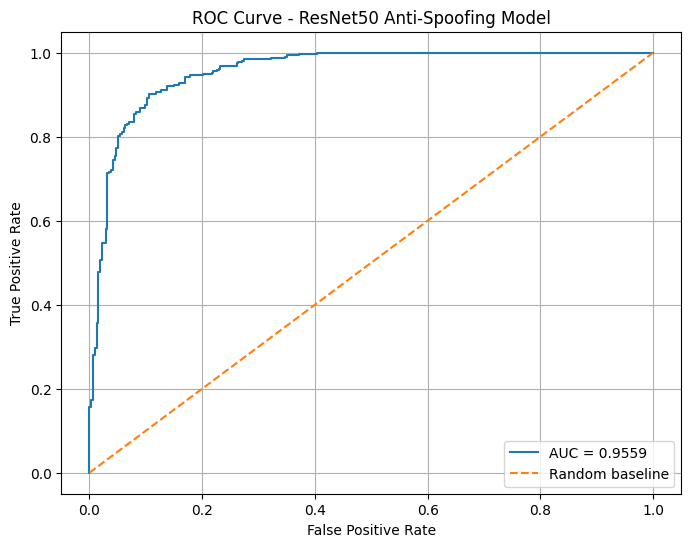

AUC: 0.9559414175017242


In [10]:
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

val_data.reset()

y_true = val_data.classes
y_pred_prob = model.predict(val_data).ravel()

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ResNet50 Anti-Spoofing Model")
plt.legend()
plt.grid(True)
plt.savefig("/Users/lasithcharuka/Desktop/spoof/resnet_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("AUC:", roc_auc)

In [11]:
y_pred_class = (y_pred_prob >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_true, y_pred_class, target_names=["REAL", "SPOOF"]))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_class))

Classification Report:
              precision    recall  f1-score   support

        REAL       0.90      0.88      0.89       314
       SPOOF       0.88      0.91      0.89       314

    accuracy                           0.89       628
   macro avg       0.89      0.89      0.89       628
weighted avg       0.89      0.89      0.89       628

Confusion Matrix:
[[275  39]
 [ 29 285]]
